In [ ]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [ ]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content/drive/MyDrive/Kaggle Json file/kaggle.json"

In [ ]:
# ============================================================
# CELL 2: INSTALL REQUIRED LIBRARIES
# ============================================================

"""
Install all libraries required for the project.

This cell only needs to be executed once
whenever a new Colab session is started.
"""

!pip install -q kagglehub
!pip install -q tensorflow
!pip install -q scikit-learn
!pip install -q matplotlib
!pip install -q seaborn

print("All required libraries installed successfully.")

All required libraries installed successfully.


In [ ]:
# ============================================================
# CELL 3: CONNECT GOOGLE DRIVE
# ============================================================

"""
Mount Google Drive so that Colab can access
the Kaggle API key (kaggle.json).
"""

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 4: CONFIGURE KAGGLE
# ============================================================

"""
Set the folder that contains kaggle.json.

Example:

MyDrive/
    Kaggle Json file/
        kaggle.json
"""

import os

os.environ["KAGGLE_CONFIG_DIR"] = "/content/drive/MyDrive/Kaggle Json file"

print("Kaggle configured successfully.")

Kaggle configured successfully.


In [ ]:
# ============================================================
# CELL 5: IMPORT LIBRARIES
# ============================================================

"""
Import all libraries required throughout
the project.
"""

import os
import random
import shutil

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import kagglehub

print("Libraries imported successfully.")

print("TensorFlow Version:", tf.__version__)

Libraries imported successfully.
TensorFlow Version: 2.20.0


In [ ]:
# ============================================================
# CELL 6: SET RANDOM SEED
# ============================================================

"""
A random seed ensures reproducibility.

This means that whenever the notebook is run,
the same random images are selected and the
same train/validation/test split is produced.
"""

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Random seed set to {SEED}.")

Random seed set to 42.


In [ ]:
# ============================================================
# CELL 7: DOWNLOAD DATASET
# ============================================================

"""
Download the skin disease dataset from Kaggle.

The dataset will be stored in Colab's temporary
working directory.
"""

dataset_path = kagglehub.dataset_download(
    "pacificrm/skindiseasedataset"
)

print("Dataset downloaded successfully.")
print(dataset_path)

Using Colab cache for faster access to the 'skindiseasedataset' dataset.
Dataset downloaded successfully.
/kaggle/input/skindiseasedataset


In [ ]:
# ============================================================
# CELL 8: EXPLORE DATASET STRUCTURE
# ============================================================

"""
Display the folders contained in the downloaded dataset.
This helps us locate the Tinea and Candidiasis folders.
"""

for root, dirs, files in os.walk(dataset_path):

    print(root)

    if len(dirs) > 0:
        print("Folders:", dirs)

    print("-" * 60)

/kaggle/input/skindiseasedataset
Folders: ['SkinDisease']
------------------------------------------------------------
/kaggle/input/skindiseasedataset/SkinDisease
Folders: ['SkinDisease']
------------------------------------------------------------
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease
Folders: ['test', 'train']
------------------------------------------------------------
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test
Folders: ['Benign_tumors', 'Unknown_Normal', 'Tinea', 'Eczema', 'Actinic_Keratosis', 'Vascular_Tumors', 'Acne', 'Infestations_Bites', 'Rosacea', 'Seborrh_Keratoses', 'Moles', 'Vitiligo', 'SkinCancer', 'Vasculitis', 'Lichen', 'Candidiasis', 'DrugEruption', 'Sun_Sunlight_Damage', 'Bullous', 'Warts', 'Psoriasis', 'Lupus']
------------------------------------------------------------
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors
------------------------------------------------------------
/kaggle/input/skindiseas

In [ ]:
# ============================================================
# CELL 9: LOCATE TINEA AND CANDIDIASIS
# ============================================================

"""
Search the downloaded dataset for the folders
named Tinea and Candidiasis.
"""

tinea_folder = None
candidiasis_folder = None

for root, dirs, files in os.walk(dataset_path):

    folder = os.path.basename(root).lower()

    if folder == "tinea":
        tinea_folder = root

    elif folder == "candidiasis":
        candidiasis_folder = root

print("=" * 50)

print("Tinea Folder:")
print(tinea_folder)

print()

print("Candidiasis Folder:")
print(candidiasis_folder)

Tinea Folder:
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/train/Tinea

Candidiasis Folder:
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/train/Candidiasis


In [ ]:
# ============================================================
# CELL 10: COUNT IMAGES
# ============================================================

"""
Count the number of images in each class.

Only image files are counted.
"""

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


def count_images(folder):

    count = 0

    for file in Path(folder).iterdir():

        if file.is_file():

            if file.suffix.lower() in IMAGE_EXTENSIONS:

                count += 1

    return count


tinea_count = count_images(tinea_folder)
candidiasis_count = count_images(candidiasis_folder)

print("=" * 50)
print("IMAGE COUNTS")
print("=" * 50)

print(f"Tinea: {tinea_count}")
print(f"Candidiasis: {candidiasis_count}")

IMAGE COUNTS
Tinea: 923
Candidiasis: 248


In [ ]:
# ============================================================
# CELL 11: CREATE BALANCED DATASET
# ============================================================

"""
This cell creates a balanced dataset for training.

The original dataset contains:
- Tinea: 923 images
- Candidiasis: 248 images

To prevent class imbalance, 248 Tinea images are randomly selected
to match the 248 available Candidiasis images.

The balanced dataset will therefore contain:

- Tinea: 248 images
- Candidiasis: 248 images

Total images = 496
"""

import shutil
from pathlib import Path

# Number of images to use from each class
TARGET_IMAGES_PER_CLASS = min(tinea_count, candidiasis_count)

# Location where the balanced dataset will be stored
balanced_dataset_path = "/content/balanced_dataset"

# Delete old balanced dataset (if it already exists)
if os.path.exists(balanced_dataset_path):
    shutil.rmtree(balanced_dataset_path)

# Create folders
balanced_tinea_path = os.path.join(
    balanced_dataset_path,
    "Tinea"
)

balanced_candidiasis_path = os.path.join(
    balanced_dataset_path,
    "Candidiasis"
)

os.makedirs(balanced_tinea_path)
os.makedirs(balanced_candidiasis_path)

# Collect image paths
tinea_images = [
    file
    for file in Path(tinea_folder).iterdir()
    if file.is_file()
    and file.suffix.lower() in IMAGE_EXTENSIONS
]

candidiasis_images = [
    file
    for file in Path(candidiasis_folder).iterdir()
    if file.is_file()
    and file.suffix.lower() in IMAGE_EXTENSIONS
]

# Randomly select images
random.seed(SEED)

selected_tinea = random.sample(
    tinea_images,
    TARGET_IMAGES_PER_CLASS
)

selected_candidiasis = random.sample(
    candidiasis_images,
    TARGET_IMAGES_PER_CLASS
)

# Copy Tinea images
for image in selected_tinea:
    shutil.copy2(
        image,
        os.path.join(
            balanced_tinea_path,
            image.name
        )
    )

# Copy Candidiasis images
for image in selected_candidiasis:
    shutil.copy2(
        image,
        os.path.join(
            balanced_candidiasis_path,
            image.name
        )
    )

print("=" * 50)
print("BALANCED DATASET CREATED")
print("=" * 50)

print(f"Tinea: {len(selected_tinea)}")
print(f"Candidiasis: {len(selected_candidiasis)}")
print(f"Total Images: {len(selected_tinea) + len(selected_candidiasis)}")

BALANCED DATASET CREATED
Tinea: 248
Candidiasis: 248
Total Images: 496


In [ ]:
# ============================================================
# CELL 12: VERIFY BALANCED DATASET
# ============================================================

"""
Verify that the balanced dataset contains
the expected number of images.
"""

balanced_tinea_count = len(list(
    Path(balanced_tinea_path).glob("*")
))

balanced_candidiasis_count = len(list(
    Path(balanced_candidiasis_path).glob("*")
))

print("=" * 50)
print("BALANCED DATASET")
print("=" * 50)

print(f"Tinea: {balanced_tinea_count}")
print(f"Candidiasis: {balanced_candidiasis_count}")
print(f"Total: {balanced_tinea_count + balanced_candidiasis_count}")

BALANCED DATASET
Tinea: 248
Candidiasis: 248
Total: 496


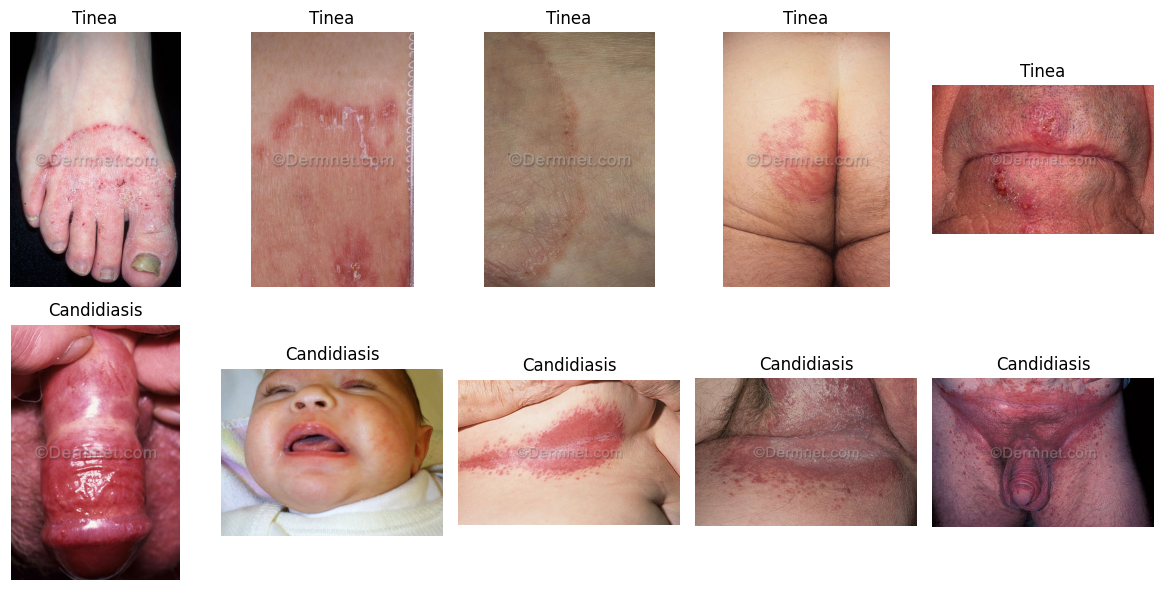

In [ ]:
# ============================================================
# CELL 13: DISPLAY SAMPLE IMAGES
# ============================================================

"""
Display a few random images from each class
to visually confirm that the dataset is correct.
"""

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Tinea samples
for i, image in enumerate(random.sample(selected_tinea, 5)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(plt.imread(image))
    plt.title("Tinea")
    plt.axis("off")

# Candidiasis samples
for i, image in enumerate(random.sample(selected_candidiasis, 5)):
    plt.subplot(2, 5, i + 6)
    plt.imshow(plt.imread(image))
    plt.title("Candidiasis")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 14: SPLIT DATASET INTO TRAIN / VALIDATION / TEST
# ============================================================

"""
This cell splits the balanced dataset into three subsets:

Training Set (70%)
Validation Set (15%)
Test Set (15%)

The split is stratified to preserve equal class
distribution in all subsets.
"""

from sklearn.model_selection import train_test_split
from pathlib import Path
import shutil

# Create destination folders
split_dataset_path = "/content/split_dataset"

# Remove old split if it exists
if os.path.exists(split_dataset_path):
    shutil.rmtree(split_dataset_path)

# Create folder structure
for split in ["train", "validation", "test"]:
    for cls in ["Tinea", "Candidiasis"]:
        os.makedirs(
            os.path.join(split_dataset_path, split, cls),
            exist_ok=True
        )

# Collect image paths and labels
image_paths = []
labels = []

for cls in ["Tinea", "Candidiasis"]:

    class_folder = os.path.join(
        balanced_dataset_path,
        cls
    )

    for image in Path(class_folder).iterdir():

        if image.is_file():

            image_paths.append(str(image))
            labels.append(cls)

# First split: Train (70%) and Temp (30%)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(

    image_paths,
    labels,

    test_size=0.30,

    random_state=SEED,

    stratify=labels
)

# Second split: Temp → Validation (15%) + Test (15%)
val_paths, test_paths, val_labels, test_labels = train_test_split(

    temp_paths,
    temp_labels,

    test_size=0.50,

    random_state=SEED,

    stratify=temp_labels
)

# Function to copy files
def copy_images(paths, labels, split_name):

    for image_path, label in zip(paths, labels):

        destination = os.path.join(

            split_dataset_path,

            split_name,

            label,

            os.path.basename(image_path)

        )

        shutil.copy2(image_path, destination)

copy_images(train_paths, train_labels, "train")
copy_images(val_paths, val_labels, "validation")
copy_images(test_paths, test_labels, "test")

print("Dataset split completed successfully.")

Dataset split completed successfully.


In [ ]:
# ============================================================
# CELL 15: VERIFY TRAIN / VALIDATION / TEST SPLIT
# ============================================================

"""
Display the number of images in each subset.
"""

def count_folder(folder):

    return len([
        file

        for file in Path(folder).iterdir()

        if file.is_file()
    ])

print("=" * 60)

for split in ["train", "validation", "test"]:

    print(f"\n{split.upper()}")

    total = 0

    for cls in ["Tinea", "Candidiasis"]:

        folder = os.path.join(

            split_dataset_path,

            split,

            cls

        )

        count = count_folder(folder)

        total += count

        print(f"{cls}: {count}")

    print(f"Total: {total}")


TRAIN
Tinea: 174
Candidiasis: 173
Total: 347

VALIDATION
Tinea: 37
Candidiasis: 37
Total: 74

TEST
Tinea: 37
Candidiasis: 38
Total: 75


In [ ]:
# ============================================================
# CELL 16: LOAD DATASETS
# ============================================================

"""
Load the training, validation and test datasets
using TensorFlow's image_dataset_from_directory().
"""

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(

    os.path.join(split_dataset_path, "train"),

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="binary",

    shuffle=True,

    seed=SEED
)

validation_ds = tf.keras.utils.image_dataset_from_directory(

    os.path.join(split_dataset_path, "validation"),

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="binary",

    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(

    os.path.join(split_dataset_path, "test"),

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="binary",

    shuffle=False
)

print("\nDatasets loaded successfully.")

Found 347 files belonging to 2 classes.
Found 74 files belonging to 2 classes.
Found 75 files belonging to 2 classes.

Datasets loaded successfully.


In [ ]:
# ============================================================
# CELL 17: OPTIMIZE DATA PIPELINE
# ============================================================

"""
Optimize dataset loading for faster training.

.cache() keeps data in memory after the first epoch.
.prefetch() prepares the next batch while the GPU
is processing the current one.
"""

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset optimization completed.")

Dataset optimization completed.


In [ ]:
# ============================================================
# CELL 18: DATA AUGMENTATION
# ============================================================

"""
Data augmentation increases the diversity of the
training data.

Only training images are augmented.

This helps reduce overfitting and improves
generalization.
"""

data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.15),

    layers.RandomZoom(0.15),

    layers.RandomContrast(0.10)

])

print("Data augmentation created successfully.")

Data augmentation created successfully.


In [ ]:
# ============================================================
# CELL 19: LOAD PRETRAINED MOBILENETV3SMALL
# ============================================================

"""
Load MobileNetV3Small pretrained on ImageNet.

The convolutional layers are frozen so that
only the classification head is trained first.
"""

base_model = tf.keras.applications.MobileNetV3Small(

    input_shape=(224, 224, 3),

    include_top=False,

    weights="imagenet"

)

base_model.trainable = False

print("MobileNetV3Small loaded successfully.")

print(f"Trainable: {base_model.trainable}")

MobileNetV3Small loaded successfully.
Trainable: False


In [ ]:
# ============================================================
# CELL 20: BUILD TRANSFER LEARNING MODEL
# ============================================================

"""
Build the complete binary classification model.

Architecture:

Input
↓
Data Augmentation
↓
Preprocessing
↓
MobileNetV3Small
↓
GlobalAveragePooling
↓
Dropout
↓
Dense
↓
Sigmoid
"""

inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v3.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(

    1,

    activation="sigmoid"

)(x)

model = keras.Model(

    inputs,

    outputs

)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 939,697 (3.58 MB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
# ============================================================
# CELL 21: COMPILE MODEL
# ============================================================

"""
Compile the model.

Binary Crossentropy is used because
this is a binary classification problem.

Adam optimizer is chosen because it
converges efficiently.
"""

model.compile(

    optimizer=keras.optimizers.Adam(

        learning_rate=0.001

    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy"

    ]

)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
# ============================================================
# CELL 22: TRAINING CALLBACKS
# ============================================================

"""
Callbacks improve training by:

1. Saving the best model.
2. Stopping early if validation loss
   stops improving.
3. Reducing the learning rate when
   progress slows.
"""

callbacks = [

    keras.callbacks.ModelCheckpoint(

        "best_model.keras",

        monitor="val_accuracy",

        save_best_only=True,

        verbose=1

    ),

    keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True

    ),

    keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.2,

        patience=2,

        verbose=1

    )

]

print("Callbacks created successfully.")

Callbacks created successfully.


In [ ]:
# ============================================================
# CELL 23: TRAIN THE TRANSFER LEARNING MODEL
# ============================================================

"""
Train the transfer learning model.

During this stage:

- MobileNetV3Small remains frozen.
- Only the newly added classification layers are trained.
- EarlyStopping prevents overfitting.
- ModelCheckpoint saves the best model.
- ReduceLROnPlateau lowers the learning rate if learning stalls.

The training history is stored for later visualization.
"""

EPOCHS = 20

history = model.fit(

    train_ds,

    validation_data=validation_ds,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1

)

print("\nInitial training completed successfully.")

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.4548 - loss: 0.8057
Epoch 1: val_accuracy improved from None to 0.48649, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.4928 - loss: 0.7760 - val_accuracy: 0.4865 - val_loss: 0.7397 - learning_rate: 0.0010
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - accuracy: 0.5719 - loss: 0.7200
Epoch 2: val_accuracy improved from 0.48649 to 0.54054, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 999ms/step - accuracy: 0.5735 - loss: 0.7346 - val_accuracy: 0.5405 - val_loss: 0.6982 - learning_rate: 0.0010
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.6659 - loss: 0.6338
Epoch 3: val_accuracy improved from 0.54054 to 0.58108, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 838ms/step 

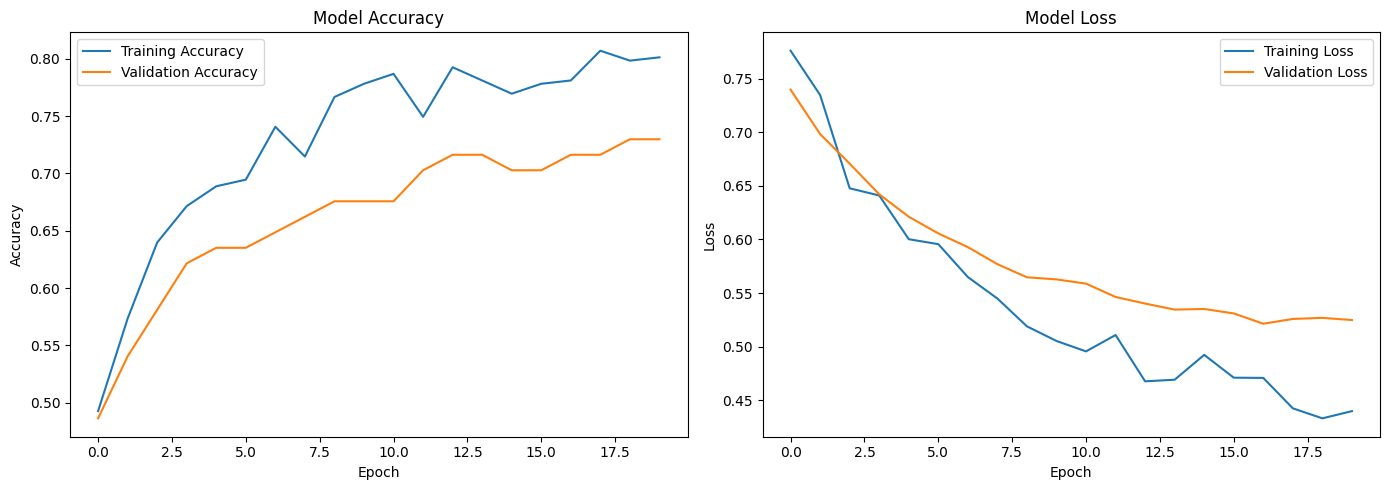

In [ ]:
# ============================================================
# CELL 24: PLOT TRAINING HISTORY
# ============================================================

"""
Plot the model's performance during training.

Two graphs are displayed:

1. Accuracy
2. Loss

These graphs help determine whether the model
is learning properly or overfitting.
"""

plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

# Loss Plot
plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# CELL 25: EVALUATE THE MODEL
# ============================================================

"""
Evaluate the trained model using the
independent test dataset.

These images were never used during training.

This provides the final estimate of the
model's performance.
"""

test_loss, test_accuracy = model.evaluate(

    test_ds,

    verbose=1

)

print("\n===================================")

print(f"Test Loss: {test_loss:.4f}")

print(f"Test Accuracy: {test_accuracy:.4f}")

print("===================================")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 0.7467 - loss: 0.5233

Test Loss: 0.5233
Test Accuracy: 0.7467


In [ ]:
# ============================================================
# CELL 26: GENERATE TEST PREDICTIONS
# ============================================================

"""
Generate predictions for all images
in the test dataset.

These predictions will be used to create
the confusion matrix and classification report.
"""

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy().astype(int))

    y_pred.extend(predictions.flatten())

print("Predictions generated successfully.")

Predictions generated successfully.


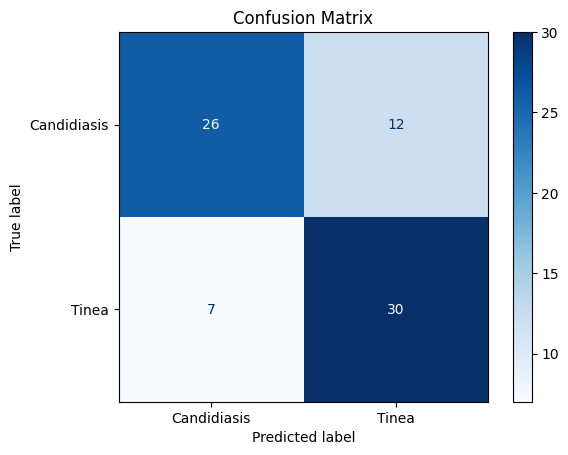

In [ ]:
# ============================================================
# CELL 27: CONFUSION MATRIX
# ============================================================

"""
Display the confusion matrix.

The confusion matrix shows:

- Correct Tinea predictions
- Correct Candidiasis predictions
- Incorrect predictions

It provides more detailed insight than
accuracy alone.
"""

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["Candidiasis", "Tinea"]

)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# ============================================================
# CELL 28: CLASSIFICATION REPORT
# ============================================================

"""
Display detailed evaluation metrics.

Metrics include:

- Precision
- Recall
- F1-score
- Accuracy

These metrics provide a comprehensive assessment
of the classifier.
"""

print(classification_report(

    y_true,

    y_pred,

    target_names=[

        "Candidiasis",

        "Tinea"

    ]

))

              precision    recall  f1-score   support

 Candidiasis       0.79      0.68      0.73        38
       Tinea       0.71      0.81      0.76        37

    accuracy                           0.75        75
   macro avg       0.75      0.75      0.75        75
weighted avg       0.75      0.75      0.75        75



In [ ]:
# ============================================================
# CELL 29: UNFREEZE TOP LAYERS (FINE-TUNING)
# ============================================================

"""
Fine-tuning improves the pretrained model by allowing
its upper convolutional layers to adapt to the skin
disease dataset.

Only the last 30 layers are unfrozen.
The remaining layers stay frozen to preserve
ImageNet features.
"""

base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("="*60)
print("Fine-tuning Enabled")
print("="*60)

trainable_layers = sum(layer.trainable for layer in base_model.layers)

print(f"Trainable Layers : {trainable_layers}")
print(f"Total Layers     : {len(base_model.layers)}")

Fine-tuning Enabled
Trainable Layers : 30
Total Layers     : 157


In [ ]:
# ============================================================
# CELL 30: RECOMPILE FOR FINE-TUNING
# ============================================================

"""
Recompile using a much smaller learning rate.

A large learning rate could destroy the useful
features learned from ImageNet.
"""

model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=1e-5

    ),

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

print("Fine-tuning model compiled successfully.")

Fine-tuning model compiled successfully.


In [ ]:
# ============================================================
# CELL 31: CONTINUE TRAINING
# ============================================================

"""
Continue training.

This stage slightly adjusts the pretrained
MobileNetV3Small weights to better recognize
Tinea and Candidiasis.
"""

FINE_TUNE_EPOCHS = 10

history_finetune = model.fit(

    train_ds,

    validation_data=validation_ds,

    epochs=FINE_TUNE_EPOCHS,

    callbacks=callbacks,

    verbose=1

)

print("\nFine-tuning completed successfully.")

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.7031 - loss: 0.5528
Epoch 1: val_accuracy did not improve from 0.72973
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.7262 - loss: 0.5261 - val_accuracy: 0.7162 - val_loss: 0.5197 - learning_rate: 1.0000e-05
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.7784 - loss: 0.5071
Epoch 2: val_accuracy did not improve from 0.72973
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 777ms/step - accuracy: 0.7522 - loss: 0.5258 - val_accuracy: 0.7162 - val_loss: 0.5178 - learning_rate: 1.0000e-05
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 900ms/step - accuracy: 0.7857 - loss: 0.5046
Epoch 3: val_accuracy did not improve from 0.72973
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 973ms/step - accuracy: 0.7550 - loss: 0.5285 - val_accuracy: 0.7162 - val_loss: 0.5163 - learning_rate: 1.0000e-05
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - accuracy: 0.7419 - loss: 0.5017
Epoch 4: val_accuracy did not improve from 0.72973
11/11 ━━━━━━━━━━━━

In [ ]:
# ============================================================
# CELL 32: FINAL TEST EVALUATION
# ============================================================

"""
Evaluate the fine-tuned model.

This gives the final performance that
will be reported in the project.
"""

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("="*60)
print("FINAL MODEL PERFORMANCE")
print("="*60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 529ms/step - accuracy: 0.7467 - loss: 0.5056
FINAL MODEL PERFORMANCE
Test Loss     : 0.5056
Test Accuracy : 0.7467


In [ ]:
# ============================================================
# CELL 33: SAVE FINAL MODEL
# ============================================================

"""
Save the final trained model.

The saved model will later be loaded
inside the Streamlit application.
"""

model.save("Tinea_Candidiasis_MobileNetV3.keras")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
# ============================================================
# CELL 34: DOWNLOAD MODEL
# ============================================================

from google.colab import files

files.download("Tinea_Candidiasis_MobileNetV3.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>